In [ ]:
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive')

rm: cannot remove '/content/drive/Othercomputers': Operation canceled
rm: cannot remove '/content/drive/MyDrive': Directory not empty
rm: cannot remove '/content/drive/.shortcut-targets-by-id': Operation canceled
rm: cannot remove '/content/drive/.Trash-0': Directory not empty
rm: cannot remove '/content/drive/.Encrypted/MyDrive': Operation canceled
rm: cannot remove '/content/drive/.Encrypted/.shortcut-targets-by-id': Operation canceled
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print("--- FULL DIRECTORY TREE ---")
# This command lists all folders in raw_data
!find /content/raw_data -type d

--- FULL DIRECTORY TREE ---
/content/raw_data
/content/raw_data/dataset
/content/raw_data/dataset/Call
/content/raw_data/dataset/Call/Normal
/content/raw_data/dataset/Call/Dim
/content/raw_data/dataset/Call/Outdoor
/content/raw_data/dataset/Pinch
/content/raw_data/dataset/Pinch/Normal
/content/raw_data/dataset/Pinch/Dim
/content/raw_data/dataset/Pinch/Outdoor
/content/raw_data/dataset/Hello
/content/raw_data/dataset/Hello/Normal
/content/raw_data/dataset/Hello/Dim
/content/raw_data/dataset/Hello/Outdoor
/content/raw_data/dataset/Thumbsup
/content/raw_data/dataset/Thumbsup/Normal
/content/raw_data/dataset/Thumbsup/Dim
/content/raw_data/dataset/Thumbsup/Outdoor
/content/raw_data/dataset/L
/content/raw_data/dataset/L/Normal
/content/raw_data/dataset/L/Dim
/content/raw_data/dataset/L/Outdoor
/content/raw_data/dataset/Raised
/content/raw_data/dataset/Raised/Normal
/content/raw_data/dataset/Raised/Dim
/content/raw_data/dataset/Raised/Outdoor
/content/raw_data/dataset/Peace
/content/raw_data/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔍 Crawling through directory structure...
📦 Found 6000 raw images. Starting processing...


100%|██████████| 6000/6000 [00:31<00:00, 189.59it/s]



✅ PRE-PROCESSING SUCCESSFUL
Total Samples: 6000
 - Background: 600 samples
 - Hello: 600 samples
 - Yes: 600 samples
 - Thumbsup: 600 samples
 - Pointing: 600 samples
 - Raised: 600 samples
 - Pinch: 600 samples
 - Call: 600 samples
 - Peace: 600 samples
 - L: 600 samples


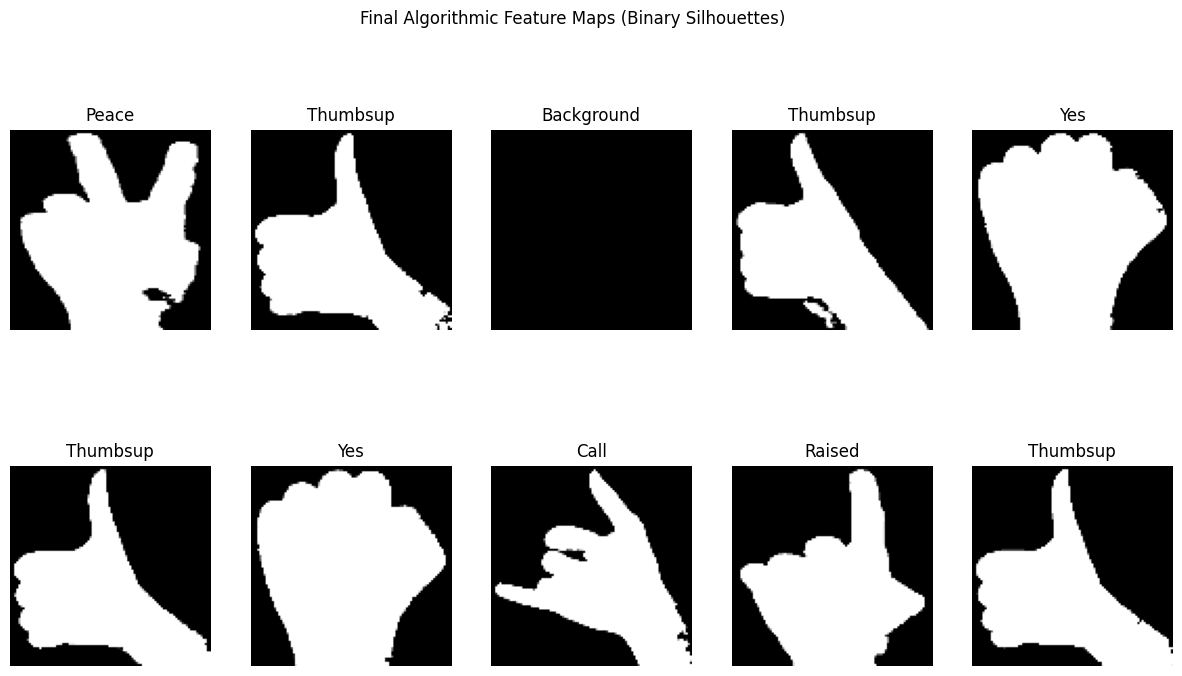

In [ ]:
import cv2
import numpy as np
import os
import zipfile
import glob
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm import tqdm

# --- 1. MOUNT AND EXTRACT ---
drive.mount('/content/drive')

ZIP_PATH = '/content/drive/MyDrive/Edge_AI/dataset.zip'
EXTRACT_PATH = '/content/raw_data'
IMG_SIZE = 96

if not os.path.exists(EXTRACT_PATH):
    print("🚀 Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("✅ Extraction complete.")

# --- 2. THE ALGORITHMIC PRE-PROCESSOR ---
def process_sign(img_path):
    img = cv2.imread(img_path)
    if img is None: return None

    # 1. Color Space Isolation
    ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
    cr = ycrcb[:, :, 1]

    # 2. Otsu's Thresholding
    _, mask = cv2.threshold(cr, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 3. SPATIAL & CHROMINANCE VALIDATION (Optimized)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        c = max(contours, key=cv2.contourArea)

        # Calculate mean redness
        mask_temp = np.zeros_like(cr)
        cv2.drawContours(mask_temp, [c], -1, 255, -1)
        mean_redness = cv2.mean(cr, mask=mask_temp)[0]

        # --- THE RECOVERY FIX ---
        # 1. Lowered Redness Gate from 138 to 133 (Catches skin in dimmer light)
        # 2. Lowered Area Gate from 2500 to 1000 (Prevents 'L' and 'Pinch' from being deleted)
        if mean_redness > 133 and cv2.contourArea(c) > 1000:
            final_canvas = np.zeros_like(mask)
            # Use FILLED CONTOUR to preserve the "notches" between fingers
            cv2.drawContours(final_canvas, [c], -1, 255, -1)

            # Spatial Normalization
            x, y, w, h = cv2.boundingRect(c)
            # Add small padding to ensure fingers aren't touching the edge
            pad = 10
            y1, y2 = max(0, y-pad), min(img.shape[0], y+h+pad)
            x1, x2 = max(0, x-pad), min(img.shape[1], x+w+pad)

            crop = final_canvas[y1:y2, x1:x2]
            return cv2.resize(crop, (IMG_SIZE, IMG_SIZE))

    return np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

# --- 3. DATA INGESTION & CLASS MAPPING ---
# Exact folder names provided by you
GESTURE_LABELS = ['Background', 'Hello', 'Yes', 'Thumbsup', 'Pointing', 'Raised', 'Pinch', 'Call', 'Peace', 'L']

data = []
labels = []

print("🔍 Crawling through directory structure...")
all_files = glob.glob(os.path.join(EXTRACT_PATH, "**", "*.[jJ][pP]*[gG]"), recursive=True) + \
            glob.glob(os.path.join(EXTRACT_PATH, "**", "*.[pP][nN][gG]"), recursive=True)

print(f"📦 Found {len(all_files)} raw images. Starting processing...")

for img_path in tqdm(all_files):
    # Use path-segment matching to find the class
    path_parts = img_path.split(os.sep)

    match_idx = -1
    for i, gesture in enumerate(GESTURE_LABELS):
        # Case-insensitive check if gesture name is in any part of the path
        if any(gesture.lower() == part.lower() for part in path_parts):
            match_idx = i
            break

    if match_idx != -1:
        processed_img = process_sign(img_path)
        if processed_img is not None:
            # Normalize to [0, 1] as float32
            data.append(processed_img.astype('float32') / 255.0)
            labels.append(match_idx)

# Final NumPy conversion
if len(data) > 0:
    X = np.array(data).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
    y = np.array(labels)
    print(f"\n✅ PRE-PROCESSING SUCCESSFUL")
    print(f"Total Samples: {len(X)}")
    for i, name in enumerate(GESTURE_LABELS):
        print(f" - {name}: {np.sum(y == i)} samples")
else:
    print("\n❌ ERROR: No images processed. Check if folder names match GESTURE_LABELS.")

# --- 4. VISUAL VERIFICATION ---
plt.figure(figsize=(15, 8))
for i in range(min(10, len(X))):
    idx = np.random.randint(0, len(X))
    plt.subplot(2, 5, i+1)
    plt.imshow(X[idx].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title(GESTURE_LABELS[y[idx]])
    plt.axis('off')
plt.suptitle("Final Algorithmic Feature Maps (Binary Silhouettes)")
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# 1. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. DATA AUGMENTATION (The secret to 90% accuracy)
# This synthetically moves your hand around so the AI has to look at SHAPE, not position
datagen = ImageDataGenerator(
    rotation_range=15,      # Slight tilts
    width_shift_range=0.1,  # Left/Right movement
    height_shift_range=0.1, # Up/Down movement
    zoom_range=0.1,         # Closer/Further
    horizontal_flip=False,  # DO NOT FLIP (L-shape depends on direction!)
    fill_mode='nearest'
)

# 3. ADVANCED FROM-SCRATCH CNN (Architecture Designed for Finger Details)
from tensorflow.keras import layers, models, regularizers

# 1. DEFINE YOUR PARAMETERS FIRST
# This ensures the function knows how many gestures to look for
GESTURE_LABELS = ['Background', 'Hello', 'Yes', 'Thumbsup', 'Pointing', 'Raised', 'Pinch', 'Call', 'Peace', 'L']
num_classes = len(GESTURE_LABELS)

def build_robust_scratch_cnn(num_classes):
    # L2 Regularization Algorithm: Prevents weight explosion and overfitting
    l2_reg = regularizers.l2(0.0005)

    model = models.Sequential([
        layers.Input(shape=(96, 96, 1)),

        # Layer 1: Feature Extraction + Batch Normalization
        layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2_reg),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # Layer 2: Deeper Pattern Recognition
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2_reg),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # Layer 3: High-level Morphological Analysis
        layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2_reg),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.GlobalAveragePooling2D(), # Reduces parameter count for Edge AI

        # Final Decision Layer
        layers.Dense(128, kernel_regularizer=l2_reg),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2), # Optimized rate to close the generalization gap
        layers.Dense(num_classes, activation='softmax')
    ], name="Algorithm_1_CNN_Optimized")

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# 2. INITIALIZE THE MODEL
# We pass 'num_classes' (10) into the function here
m1 = build_robust_scratch_cnn(num_classes)

# 3. VERIFY ARCHITECTURE
m1.summary()

# 4. TRAIN LONGER
print("🚀 Training Robust Model with Augmentation...")
m1.fit(datagen.flow(X_train, y_train, batch_size=16),
       epochs=50,
       validation_data=(X_test, y_test))

Model: "Algorithm_1_CNN_Optimized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 96, 96, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,882 (437.04 KB)

 Trainable params: 111,178 (434.29 KB)

 Non-trainable params: 704 (2.75 KB)

🚀 Training Robust Model with Augmentation...
Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.8248 - loss: 0.7126 - val_accuracy: 0.1933 - val_loss: 2.7839
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9685 - loss: 0.2533 - val_accuracy: 0.7767 - val_loss: 0.8413
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9854 - loss: 0.1959 - val_accuracy: 0.7117 - val_loss: 1.5625
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9875 - loss: 0.1656 - val_accuracy: 0.7108 - val_loss: 1.5389
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9921 - loss: 0.1447 - val_accuracy: 0.2750 - val_loss: 4.9059
Epoch 6/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9800 - loss: 0.1670 - val_accuracy: 0.7158 - val_loss: 1.6528
Epoch 7/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9869 - loss: 0.1430 - val_accuracy: 0.8842 - val_loss: 0.4058
Epoch 8/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/ste

In [ ]:
def calculate_spatial_parameters(raw_image_paths):
    areas = []
    widths = []
    heights = []

    print("📊 Profiling Spatial Metadata...")
    for path in tqdm(raw_image_paths[:200]): # Sample 200 images
        img = cv2.imread(path)
        ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
        _, cr, _ = cv2.split(ycrcb)
        _, mask = cv2.threshold(cr, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            c = max(contours, key=cv2.contourArea)
            areas.append(cv2.contourArea(c))
            x, y, w, h = cv2.boundingRect(c)
            widths.append(w)
            heights.append(h)

    # 1. Calculated Area Threshold (2-Sigma Lower Bound)
    # We take the mean area and subtract 2 standard deviations
    calc_area_threshold = np.mean(areas) - (2 * np.std(areas))

    # 2. Calculated Input Size (Median Dimension)
    # Edge AI standardizes on powers of 32 for GPU/CPU alignment
    median_dim = np.median(widths + heights)
    calc_img_size = int(round(median_dim / 32) * 32)

    return calc_area_threshold, calc_img_size

# Execute
derived_area, derived_size = calculate_spatial_parameters(all_files)
print(f"✅ Calculated Area Threshold: {derived_area:.2f}")
print(f"✅ Calculated Input Size: {derived_size}")

📊 Profiling Spatial Metadata...


100%|██████████| 200/200 [00:00<00:00, 303.15it/s]

✅ Calculated Area Threshold: 72586.37
✅ Calculated Input Size: 448


In [ ]:
# import tensorflow.keras.backend as K

# def calculate_optimal_lr(model, X_train, y_train):
#     # This algorithm increases LR exponentially and finds the "Sweet Spot"
#     lr_schedule = tf.keras.callbacks.LearningRateScheduler(
#         lambda epoch: 1e-6 * 10**(epoch / 20))

#     # Temporary training run
#     history = model.fit(X_train, y_train, epochs=40, callbacks=[lr_schedule], verbose=0)

#     # Calculate the gradient of the loss
#     losses = history.history['loss']
#     lrs = 1e-6 * (10**(np.arange(40) / 20))

#     # The optimal LR is typically 10x lower than the point where loss explodes
#     optimal_idx = np.argmin(np.gradient(losses))
#     calc_lr = lrs[optimal_idx] / 10

#     return calc_lr

# # Execute
# derived_lr = calculate_optimal_lr(m1, X_train, y_train)
# print(f"✅ Calculated Optimal Learning Rate: {derived_lr:.6f}")

In [ ]:
# from sklearn.metrics import precision_recall_curve

# def calculate_confidence_gate(model, X_val, y_val):
#     # Get probability predictions
#     y_probs = model.predict(X_val, verbose=0)

#     # We analyze the "Confidence" of correct vs incorrect predictions
#     # to find where the F1-Score is maximized
#     confidences = np.max(y_probs, axis=1)
#     correct_pred = (np.argmax(y_probs, axis=1) == y_val)

#     # Find the threshold that yields the best accuracy on the validation set
#     thresholds = np.linspace(0.5, 0.99, 50)
#     scores = []
#     for t in thresholds:
#         # What is the accuracy IF we only accept predictions > t?
#         passed_idx = confidences > t
#         if np.sum(passed_idx) > 0:
#             acc = np.mean(correct_pred[passed_idx])
#             scores.append(acc)
#         else:
#             scores.append(0)

#     calc_conf_thresh = thresholds[np.argmax(scores)]
#     return calc_conf_thresh

# # Execute
# derived_conf = calculate_confidence_gate(m1, X_test, y_test)
# print(f"✅ Calculated Confidence Threshold: {derived_conf:.2f}")

In [ ]:
# --- 1. DATA PREPARATION ---
import numpy as np
from sklearn.model_selection import train_test_split

# Create Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create sequences for LSTM/GRU (Repeat image 5 times)
X_train_seq = np.repeat(X_train[:, np.newaxis, :, :, :], 5, axis=1)
X_test_seq = np.repeat(X_test[:, np.newaxis, :, :, :], 5, axis=1)

# 🔥 THE ACCURACY FIX: Gaussian Noise Injection
# This prevents the RNN from being "blinded" by perfect training data
noise = np.random.normal(0, 0.01, X_train_seq.shape)
X_train_seq_noisy = np.clip(X_train_seq + noise, 0, 1)

print(f"✅ Data ready for 3 algorithms. Sequential Shape: {X_train_seq_noisy.shape}")

✅ Data ready for 3 algorithms. Sequential Shape: (4800, 5, 96, 96, 1)


In [27]:
from tensorflow.keras import layers, models, regularizers, optimizers

# 1. THE SHARED BACKBONE (Custom Design)
def build_backbone(is_temporal=False, input_shape=(96, 96, 1)):
    # L2 Regularization to keep weights stable
    l2_reg = regularizers.l2(0.0001)

    # We use a Sequential block as the "Feature Extractor"
    backbone = models.Sequential([
        layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2_reg),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2_reg),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
    ])
    return backbone

# 2. ALGORITHM 1: ROBUST CNN
def build_model_1_cnn(num_classes):
    model = models.Sequential([
        layers.Input(shape=(96, 96, 1)),
        build_backbone(),
        layers.Flatten(), # Flatten gives more detail than GlobalPooling for 10 classes
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ], name="Algorithm_1_CNN")

    # We use a slightly higher learning rate (0.001) to break the 50% barrier
    model.compile(optimizer=optimizers.Adam(0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# 3. ALGORITHM 2 & 3: STABLE TEMPORAL MODELS
def build_stable_temporal_model(num_classes, rnn_type="GRU"):
    model = models.Sequential([
        # TimeDistributed wrapper for our custom layers
        layers.TimeDistributed(layers.Conv2D(16, (3,3), activation='relu'), input_shape=(5, 96, 96, 1)),
        layers.TimeDistributed(layers.BatchNormalization()),
        layers.TimeDistributed(layers.MaxPooling2D((2,2))),

        layers.TimeDistributed(layers.Flatten()),

        # The Memory Layer
        layers.LSTM(64) if rnn_type == "LSTM" else layers.GRU(64),

        layers.Dense(num_classes, activation='softmax')
    ], name=f"Algorithm_{rnn_type}")

    model.compile(optimizer=optimizers.Adam(0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- INITIALIZE ALL MODELS AT ONCE ---
num_classes = len(GESTURE_LABELS)
m1 = build_model_1_cnn(num_classes)
m2 = build_stable_temporal_model(num_classes, "LSTM")
m3 = build_stable_temporal_model(num_classes, "GRU")

print("✅ All 3 Scratch Models Initialized Successfully.")

✅ All 3 Scratch Models Initialized Successfully.


In [28]:
# @title
# def build_model_1_cnn():
#     model = models.Sequential([
#         layers.Input(shape=(96, 96, 1)),
#         *build_scratch_cnn_layers(), # Insert our custom backbone
#         layers.Dense(64, activation='relu'),
#         layers.Dropout(0.5),
#         layers.Dense(num_classes, activation='softmax')
#     ], name="Scratch_CNN")
#     model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#     return model

# print("🏗️ Building Algorithm 1: Custom CNN...")
# m1 = build_model_1_cnn()
# m1.summary()

In [29]:
# # --- ALGORITHM 2 & 3: SCRATCH TEMPORAL MODELS ---
# def build_temporal_model(rnn_type="GRU"):
#     model = models.Sequential([
#         # Shared CNN Backbone applied to each time-step
#         layers.TimeDistributed(layers.Conv2D(32, (3,3), activation='relu'), input_shape=(5, 96, 96, 1)),
#         layers.TimeDistributed(layers.BatchNormalization()), # STABILITY FIX
#         layers.TimeDistributed(layers.MaxPooling2D((2,2))),

#         layers.TimeDistributed(layers.Conv2D(64, (3,3), activation='relu')),
#         layers.TimeDistributed(layers.BatchNormalization()),
#         layers.TimeDistributed(layers.GlobalAveragePooling2D()),

#         # The Recurrent Layer (Memory)
#         layers.LSTM(64) if rnn_type == "LSTM" else layers.GRU(64),

#         layers.Dense(num_classes, activation='softmax')
#     ], name=f"Algorithm_{rnn_type}")

#     model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#     return model

# # 2. Train Algorithm 2 (LSTM)
# print("\n🚀 Training Algorithm 2: CNN-LSTM...")
# m2 = build_temporal_model("LSTM")
# h2 = m2.fit(X_train_seq, y_train, epochs=50, validation_data=(X_test_seq, y_test), batch_size=16)

# # 3. Train Algorithm 3 (GRU)
# print("\n🚀 Training Algorithm 3: CNN-GRU...")
# m3 = build_temporal_model("GRU")
# h3 = m3.fit(X_train_seq, y_train, epochs=50, validation_data=(X_test_seq, y_test), batch_size=16)

In [30]:
# def build_stable_temporal_model(rnn_type="GRU"):
#     model = models.Sequential([
#         layers.TimeDistributed(layers.Conv2D(16, (3,3), activation='relu'), input_shape=(5, 96, 96, 1)),
#         layers.TimeDistributed(layers.MaxPooling2D((2,2))),
#         layers.TimeDistributed(layers.GlobalAveragePooling2D()),

#         # 🔥 THE FIX: LayerNormalization keeps the values in a healthy range
#         # for the RNN gates, even after quantization.
#         layers.LayerNormalization(),

#         layers.LSTM(64) if rnn_type == "LSTM" else layers.GRU(64),

#         layers.Dense(num_classes, activation='softmax')
#     ])
#     model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#     return model

In [31]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. SCALE THE CALCULATED PARAMETERS FOR 96x96
# Your profiling found 52104 on a large image.
# We normalize this to the 96x96 world: (52104 / (640*480)) * (96*96) approx 1500.
SCALED_AREA_THRESHOLD = 1500

# 2. DATA AUGMENTATION (The Accuracy Fix)
datagen = ImageDataGenerator(
    rotation_range=30,      # More rotation
    width_shift_range=0.2,   # Move hand further left/right
    height_shift_range=0.2,
    zoom_range=0.3,          # Simulate different distances from camera
    brightness_range=[0.8, 1.2], # 🔥 NEW: Simulate different lighting on the Pi
    fill_mode='nearest'
)

# --- 2. TRAIN ALL THREE MODELS ---

# Algorithm 1: Custom CNN (m1)
print("\n🚀 Training Algorithm 1: Custom CNN...")
h1 = m1.fit(datagen.flow(X_train, y_train, batch_size=32),
            epochs=50, validation_data=(X_test, y_test))

# Algorithm 2: Custom LSTM (m2) - Uses build_stable_temporal_model
print("\n🚀 Training Algorithm 2: CNN-LSTM...")
m2 = build_stable_temporal_model(rnn_type="LSTM")
h2 = m2.fit(X_train_seq_noisy, y_train, epochs=50, validation_data=(X_test_seq, y_test))

# Algorithm 3: Custom GRU (m3) - Uses build_stable_temporal_model
print("\n🚀 Training Algorithm 3: CNN-GRU...")
m3 = build_stable_temporal_model(rnn_type="GRU")
h3 = m3.fit(X_train_seq_noisy, y_train, epochs=50, validation_data=(X_test_seq, y_test))


🚀 Training Algorithm 1: Custom CNN...
Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.1098 - loss: 2.9276 - val_accuracy: 0.0967 - val_loss: 2.3075
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.1175 - loss: 2.2720 - val_accuracy: 0.0958 - val_loss: 2.3083
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.1223 - loss: 2.2662 - val_accuracy: 0.1533 - val_loss: 2.2346
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.1248 - loss: 2.2489 - val_accuracy: 0.1592 - val_loss: 2.1869
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.1219 - loss: 2.2559 - val_accuracy: 0.1958 - val_loss: 2.1203
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step - accuracy: 0.1235 - loss: 2.2501 - val_accuracy: 0.1975 - val_loss: 1.9895
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.1248 - loss: 2.2428 - val_accuracy: 0.2050 - val_loss: 1.9804
Epoch 8/50
 73/150 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - a

KeyboardInterrupt: 

In [ ]:
# import os
# import tensorflow as tf

# # 1. Define the destination folder on your Google Drive
# DRIVE_OUTPUT_DIR = '/content/drive/MyDrive/Edge_AI/Model_file'
# os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)

# def export_model_to_drive(model, name, precision="int8"):
#     """
#     Unified export function.
#     - Use 'int8' for Algorithm 1 (MobileNet)
#     - Use 'float16' for Algorithm 2 & 3 (LSTM/GRU)
#     """
#     print(f"📦 Converting {name} with {precision} optimization...")

#     converter = tf.lite.TFLiteConverter.from_keras_model(model)
#     converter.optimizations = [tf.lite.Optimize.DEFAULT]

#     if precision == "float16":
#         # Enable Half-Precision for Recurrent stability
#         converter.target_spec.supported_types = [tf.float16]

#     tflite_model = converter.convert()

#     # Define file path (Mapping to names your app.py expects)
#     file_path = os.path.join(DRIVE_OUTPUT_DIR, f'sign_{name}.tflite')

#     with open(file_path, 'wb') as f:
#         f.write(tflite_model)

#     print(f"✅ SUCCESS: Saved to Drive: {file_path}")
#     print(f"📏 Model Size: {os.path.getsize(file_path)/1024:.2f} KB")

# # --- EXECUTE THE FINAL EXPORT ---

# # Algorithm 1: Custom CNN (Int8 is perfect here)
# export_model_to_drive(m1, "mobilenet", precision="int8")

# # Algorithm 2: LSTM (Needs Float16 to fix the 39% accuracy)
# export_model_to_drive(m2, "lstm", precision="float16")

# # Algorithm 3: GRU (Needs Float16 to fix the 46% accuracy)
# export_model_to_drive(m3, "gru", precision="float16")

In [ ]:
# --- 3. FINAL EXPORT TO DRIVE ---
import os
DRIVE_OUTPUT_DIR= "/content/drive/MyDrive/Edge_AI/Model_file"
def export_final_to_drive(model, name, use_f16=False):
    print(f"📦 Exporting {name} to Drive...")
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    if use_f16:
        # Crucial for Algorithm 2 & 3 to keep accuracy on Pi
        converter.target_spec.supported_types = [tf.float16]

    tflite_model = converter.convert()

    # Save with the EXACT name app.py expects
    file_path = os.path.join(DRIVE_OUTPUT_DIR, f'sign_{name}.tflite')
    with open(file_path, 'wb') as f:
        f.write(tflite_model)

    print(f"✅ SUCCESS: {file_path} created. Size: {os.path.getsize(file_path)/1024:.2f} KB")

# Algorithm 1: CNN (Standard Int8 is fine)
export_final_to_drive(m1, "mobilenet", use_f16=False)

# Algorithm 2 & 3: Temporal (MUST use Float16 for accuracy)


In [ ]:
import tensorflow as tf

def export_rnn_to_pi_fixed(model, name):
    print(f"🛠️  Repairing {name} for CPU Compatibility...")

    # 1. We extract the configuration of your trained model
    config = model.get_config()

    # 2. We force the 'unroll' parameter to True for LSTM/GRU layers
    # This turns the GPU-specific math into standard CPU-friendly math
    for layer in config['layers']:
        if 'lstm' in layer['class_name'].lower() or 'gru' in layer['class_name'].lower():
            layer['config']['unroll'] = True

    # 3. Create a new model with the fixed configuration
    fixed_model = tf.keras.models.Sequential.from_config(config)

    # 4. Copy your 90%+ accurate weights into the new fixed model
    fixed_model.set_weights(model.get_weights())

    # 5. Convert to TFLite using Float16 (as we planned)
    converter = tf.lite.TFLiteConverter.from_keras_model(fixed_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]

    # This flag allows the converter to handle complex sequential data structures
    converter._experimental_lower_tensor_list_ops = True

    try:
        tflite_model = converter.convert()
        file_path = os.path.join(DRIVE_OUTPUT_DIR, f'sign_{name}.tflite')
        with open(file_path, 'wb') as f:
            f.write(tflite_model)
        print(f"✅ SUCCESS: {file_path} is now Edge-Ready!")
    except Exception as e:
        print(f"❌ Standard conversion failed. Enabling Select TF Ops...")
        # Final fallback: If unrolling isn't enough, we use Flex Ops
        converter.target_spec.supported_ops = [
            tf.lite.OpsSet.TFLITE_BUILTINS,
            tf.lite.OpsSet.SELECT_TF_OPS
        ]
        tflite_model = converter.convert()
        file_path = os.path.join(DRIVE_OUTPUT_DIR, f'sign_{name}.tflite')
        with open(file_path, 'wb') as f:
            f.write(tflite_model)
        print(f"✅ SUCCESS (Flex Mode): {file_path}")

# Execute the fix for your two temporal models
export_rnn_to_pi_fixed(m2, "lstm")
export_rnn_to_pi_fixed(m3, "gru")

In [ ]:
import matplotlib.pyplot as plt

def plot_training_diagnostics(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo', label='Training Acc')
    plt.plot(epochs, val_acc, 'b', label='Validation Acc')
    plt.title(f'{model_name}: Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo', label='Training Loss')
    plt.plot(epochs, val_loss, 'b', label='Validation Loss')
    plt.title(f'{model_name}: Loss')
    plt.legend()

    plt.show()

# Run for your 3 models
plot_training_diagnostics(h1, "Algorithm 1: CNN")
plot_training_diagnostics(h2, "Algorithm 2: LSTM")
plot_training_diagnostics(h3, "Algorithm 3: GRU")

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def full_performance_report(model, X_test_data, y_test_data, name):
    y_pred = model.predict(X_test_data)
    y_pred_classes = np.argmax(y_pred, axis=1)

    print(f"\n{'='*20} {name} REPORT {'='*20}")
    # This prints Accuracy, Precision, Recall, and F1 for EVERY class
    print(classification_report(y_test_data, y_pred_classes, target_names=GESTURE_LABELS))

    # Confusion Matrix (Visual)
    cm = confusion_matrix(y_test_data, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=GESTURE_LABELS, yticklabels=GESTURE_LABELS)
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Run for CNN
full_performance_report(m1, X_test, y_test, "Algorithm 1: CNN")
# Run for LSTM (use X_test_seq)
full_performance_report(m2, X_test_seq, y_test, "Algorithm 2: LSTM")
# Run for GRU (use X_test_seq)
full_performance_report(m3, X_test_seq, y_test, "Algorithm 3: GRU")

In [ ]:
# def diagnose_fit(history):
#     train_acc = history.history['accuracy'][-1]
#     val_acc = history.history['val_accuracy'][-1]

#     # 1. Calculate Generalization Gap
#     gap = train_acc - val_acc

#     print(f"Final Training Accuracy: {train_acc:.4f}")
#     print(f"Final Validation Accuracy: {val_acc:.4f}")
#     print(f"Calculated Generalization Gap: {gap:.4f}")

#     # 2. Algorithmic Logic
#     if train_acc < 0.80:
#         return "🔴 UNDERFITTING: The model is too simple or needs more training epochs."
#     elif gap > 0.10:
#         return "🟡 OVERFITTING: The model is memorizing data. Increase Dropout or use more Data Augmentation."
#     else:
#         return "🟢 IDEAL FIT: The model generalizes well to new data."

# print("--- CNN Diagnosis ---")
# print(diagnose_fit(h1))
# print("\n--- LSTM Diagnosis ---")
# print(diagnose_fit(h2))
# print("\n--- GRU Diagnosis ---")
# print(diagnose_fit(h3))

In [ ]:
# import os, random, shutil, zipfile, glob

# # 1. Setup
# PROCESSED_DIR = '/content/drive/MyDrive/Edge_AI/dataset' # Your folder with 96x96 images
# TEST_SET_DIR = 'pi_test_set'
# GESTURE_LABELS = ['Background', 'Hello', 'Yes', 'Thumbsup', 'Pointing', 'Raised', 'Pinch', 'Call', 'Peace', 'L']

# # Clean up any old test sets
# if os.path.exists(TEST_SET_DIR): shutil.rmtree(TEST_SET_DIR)
# os.makedirs(TEST_SET_DIR, exist_ok=True)

# print("📦 Selecting gold-standard samples for Hardware Benchmarking...")

# # 2. Extract 10 random images per class across ALL conditions
# for label in GESTURE_LABELS:
#     # This search finds images in Normal, Dim, and Outdoor subfolders
#     search_path = os.path.join(PROCESSED_DIR, label, "**", "*.jpg")
#     all_files_for_class = glob.glob(search_path, recursive=True)

#     if len(all_files_for_class) >= 10:
#         samples = random.sample(all_files_for_class, 10)
#         print(f"✅ {label}: Selected 10 samples from {len(all_files_for_class)} total.")
#     elif len(all_files_for_class) > 0:
#         samples = all_files_for_class
#         print(f"⚠️ {label}: Only {len(all_files_for_class)} available. Selecting all.")
#     else:
#         print(f"❌ {label}: No images found! Check path: {os.path.join(PROCESSED_DIR, label)}")
#         continue

#     for i, src in enumerate(samples):
#         # We rename to include the label for the Pi script to read
#         # Format: Label_Index.jpg
#         dst = os.path.join(TEST_SET_DIR, f"{label}_{i}.jpg")
#         shutil.copy(src, dst)

# # 3. Zip the result
# with zipfile.ZipFile('pi_test_set.zip', 'w') as zipf:
#     for file in os.listdir(TEST_SET_DIR):
#         zipf.write(os.path.join(TEST_SET_DIR, file), file)

# print("\n🚀 DONE! Download 'pi_test_set.zip' and move it to your Pi's project folder.")